# Fine-tuning DarijaBERT (SI2M-Lab/DarijaBERT)

In this notebook, we will train a text classification model using a specific dataset. We will use Hugging Face's `transformers` library to load a pre-trained BERT model, apply LoRA (Low-Rank Adaptation) configuration, and train the model on an annotated dataset. At the end, the fine-tuned model will be saved directly to your Hugging Face Hub account.

## Steps:
1. Load and preprocess the data.
2. Configure and load the pre-trained model.
3. Apply LoRA to the model.
4. Configure and train the model.
5. Save the final model to Hugging Face Hub.


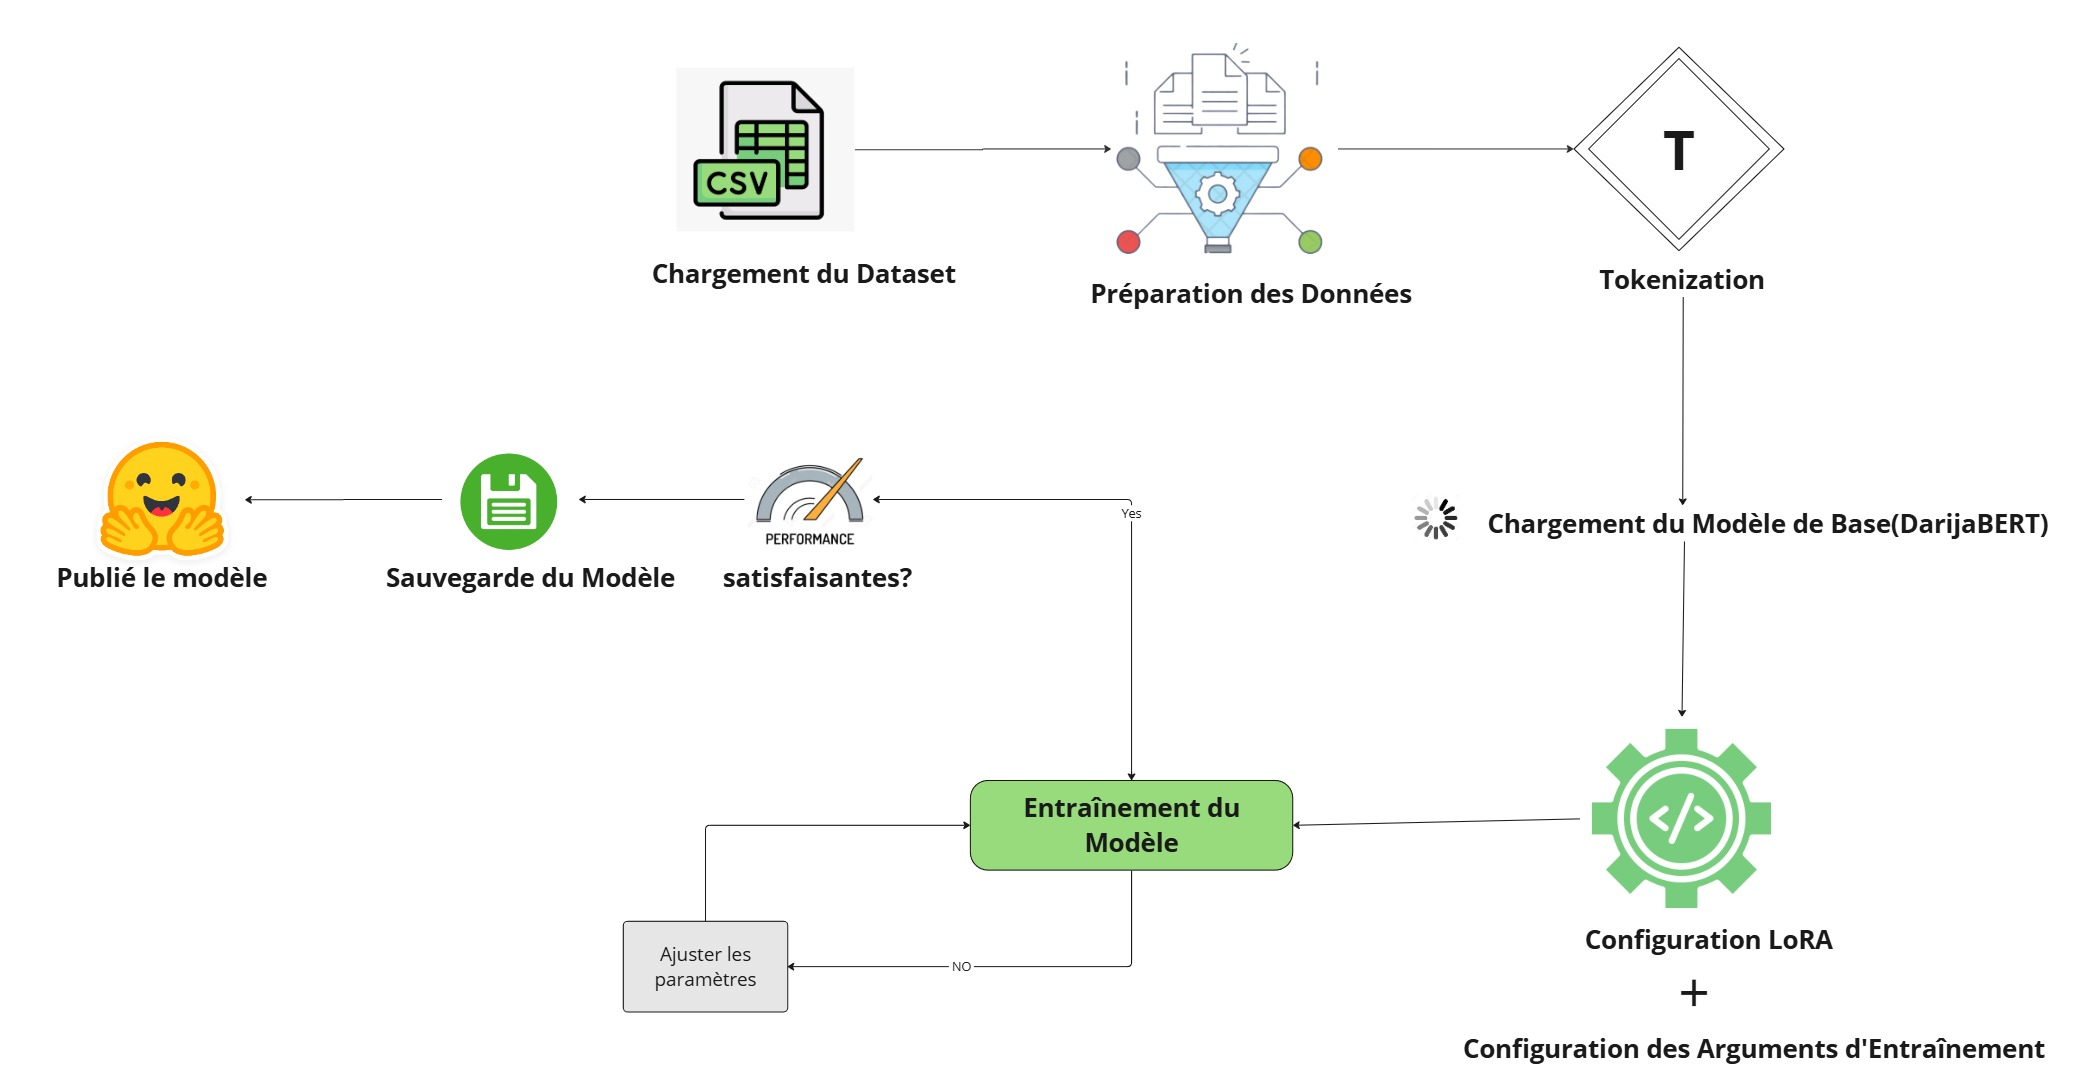

In [1]:
# Import necessary libraries
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from transformers import EvalPrediction
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 127.7 MB/s eta 0:00:00


## 1. Load and Preprocess the Data

We start by loading the dataset and verifying it contains the required columns for training. We then encode text labels as integers and split the data into training and validation sets.


In [4]:
# Load the dataset
df = pd.read_csv('/content/data/dataset_darija2.csv')

# Verify required columns exist
if 'Text' not in df.columns or 'Label' not in df.columns:
    raise ValueError("The dataset must contain 'Text' and 'Label' columns.")

# Encode labels as integers
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)

# Convert DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

## 2. Load and Tokenize the Data

Next, we load a pre-trained tokenizer for the model and apply it to our data. The tokenizer converts raw text into numerical tokens so it can be processed by the model.


In [5]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("SI2M-Lab/DarijaBERT")

# Tokenize the data with padding
def tokenize_function(examples):
    return tokenizer(
        examples['Text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Apply the tokenizer to both training and validation sets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Add labels to the dataset
train_dataset = train_dataset.map(lambda x: {'labels': x['Label']})
val_dataset = val_dataset.map(lambda x: {'labels': x['Label']})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/307 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/879k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.51M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## 3. Configure the Model with LoRA

We now load a pre-trained sequence classification model. We then apply LoRA configuration to add a low-rank adaptation mechanism to the model's layers, improving training efficiency.


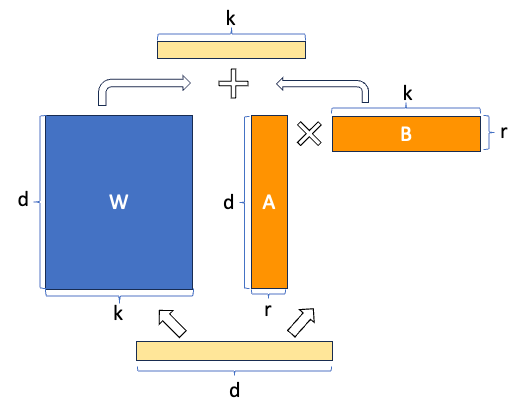

In [7]:
!pip install -q torchao --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.5 MB/s eta 0:00:00


In [8]:
# Load the model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    "SI2M-Lab/DarijaBERT",
    num_labels=len(label_encoder.classes_)
)

# LoRA configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,         # Sequence classification task
    r=8,                                # Rank of the decomposition (smaller = fewer parameters)
    lora_alpha=32,                      # Scaling factor for the adaptation matrices
    lora_dropout=0.1,                   # Dropout rate applied to LoRA matrices during training
    target_modules=["query", "value"],  # Target attention modules for adaptation
)
model = get_peft_model(model, lora_config)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: SI2M-Lab/DarijaBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

## 4. Define Metrics and Training Arguments

We define an evaluation function to measure model performance during training using accuracy, precision, recall, and F1 metrics. We then configure the training arguments.


In [9]:
# Define evaluation metrics
def compute_metrics(p: EvalPrediction):
    preds = p.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted')
    acc = accuracy_score(p.label_ids, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,   # Load the best model checkpoint at the end
    metric_for_best_model="f1",
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 5. Train and Save the Model

We initialize the `Trainer` with the defined arguments and start training. After training, we save the model and tokenizer, then push them directly to your Hugging Face Hub account.


In [10]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

# Train the model
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.231821,1.147725,0.847000,0.843905,0.861701,0.847000
2,0.361629,0.248856,0.993500,0.993483,0.993882,0.993500
3,0.076253,0.044759,0.997000,0.997001,0.997092,0.997000
4,0.036140,0.022932,0.993500,0.993483,0.993882,0.993500
5,0.014538,0.017179,0.993500,0.993483,0.993882,0.993500
6,0.022590,0.011021,0.997000,0.997001,0.997092,0.997000
7,0.006960,0.009322,0.997000,0.997001,0.997092,0.997000
8,0.005993,0.009326,0.997000,0.997001,0.997092,0.997000
9,0.026234,0.008330,0.997000,0.997001,0.997092,0.997000
10,0.004997,0.008044,0.997000,0.997001,0.997092,0.997000


TrainOutput(global_step=5000, training_loss=0.2974802692078054, metrics={'train_runtime': 1441.7586, 'train_samples_per_second': 55.488, 'train_steps_per_second': 3.468, 'total_flos': 5281190952960000.0, 'train_loss': 0.2974802692078054, 'epoch': 10.0})

In [13]:
from transformers import BertForSequenceClassification, BertTokenizer

model = BertForSequenceClassification.from_pretrained(
    "/content/results/checkpoint-5000",
    num_labels=10
)
tokenizer = BertTokenizer.from_pretrained(
    "/content/results/checkpoint-5000"
)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: SI2M-Lab/DarijaBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were 

Loading weights:   0%|          | 0/48 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: /content/results/checkpoint-5000
Key                                       | Status     | 
------------------------------------------+------------+-
classifier.bias                           | UNEXPECTED | 
classifier.weight                         | UNEXPECTED | 
classifier.modules_to_save.default.weight | MISSING    | 
classifier.modules_to_save.default.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


## 6. Display the Confusion Matrix

After training the model, it is useful to visualize its performance by displaying a confusion matrix. This helps us understand how the model makes predictions for each class.


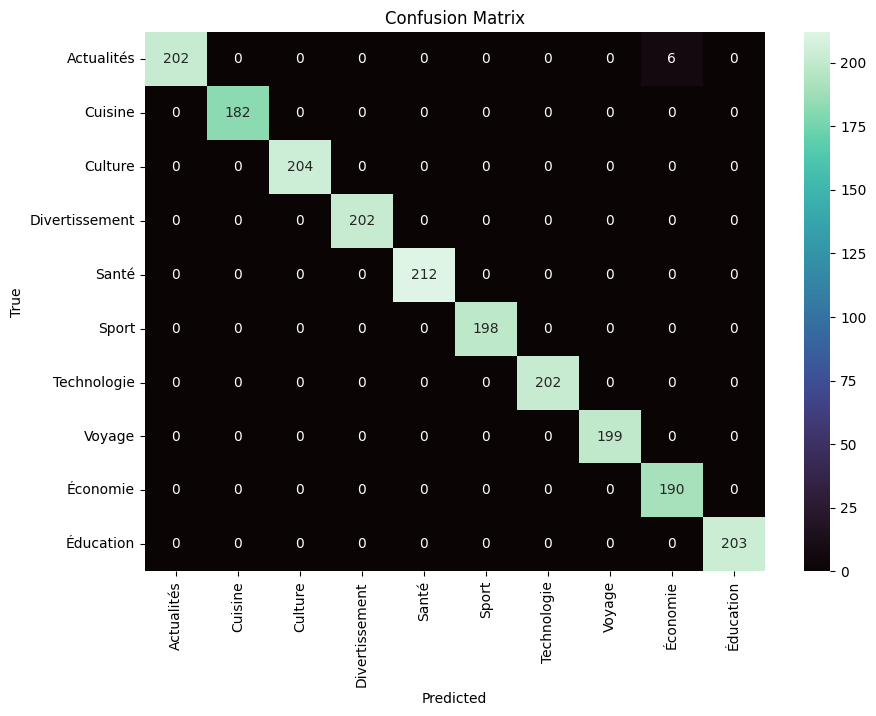

In [23]:
# Import libraries for the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions on the validation set
pred_labels = trainer.predict(val_dataset).predictions.argmax(axis=-1)
val_labels = val_dataset["labels"]

# Compute confusion matrix
conf_matrix = confusion_matrix(val_labels, pred_labels)

# Display the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix, annot=True, fmt='d', cmap='mako',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [22]:
from huggingface_hub import login
import os

hf_token = os.environ.get("HF_TOKEN")
login(token=hf_token)
repo_name = "DarijaBERT-finetuned_model_with_LORA"
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print(f"Done! → https://huggingface.co/HanaSoummar/{repo_name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 1.22MB / 1.22MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Done! → https://huggingface.co/HanaSoummar/DarijaBERT-finetuned_model_with_LORA
